In [4]:
import torch
import torch.nn as nn
from typing import Any, Dict, List
import matplotlib.pyplot as plt
import numpy as np
import time

from src.dataset.dataset import get_dataloaders
from src.utils import set_seed, load_yaml_config
from src.models.student import PhisatNetEncoder, PhisatNetDecoder

## Setup

In [8]:
set_seed(42)

config = load_yaml_config()
BASELINE_MODE = 0.5

SEG_TASKS = {
    'lulc': 11, 
    'anomaly_detection': 9, 
    'burned_area': 4, 
    'clouds': 2,
    'worldfloods': 3
}

PATH_ENCODER = "/shared/projects/phisat2/bad_weights/encoder_sim_base.pth"
PATH_TASKS = {}
for task in SEG_TASKS.keys():
    PATH_TASKS[task] = f"/shared/projects/phisat2/bad_weights/decoder_{task}.pth"

In [9]:
train_loader, val_loader, test_loader = get_dataloaders(
    config=config,
    baseline_mode=BASELINE_MODE,
    batch_size=8,
    num_workers=4
)

Filtering 35 bad product_ids...
Keeping 253739 out of 259150 (97.91%).
Data splits initialized -> Train: 177617, Val: 38060, Test: 38062
Running in Baseline Mode: 0.5


In [10]:
# We put the encoder on GPU
encoder = PhisatNetEncoder(n_channels=8, base_filters=16, depth=3, channel_multipliers=[1,2,4,8]).to("cuda")
encoder.load_state_dict(torch.load(PATH_ENCODER, weights_only=True))
encoder.eval()

# We put the segmentation heads on CPU since they are small and we will move them one by one to GPU during inference
seg_heads = {}
for task_name, n_classes in SEG_TASKS.items():
    head = PhisatNetDecoder(n_classes=n_classes, base_filters=16, depth=3, channel_multipliers=[1,2,4,8])
    head.load_state_dict(torch.load(PATH_TASKS[task_name], weights_only=True), strict=False)
    head.eval()
    seg_heads[task_name] = head

## Inference

In [11]:
def multi_task_inference(images, active_tasks, encoder, seg_heads, device="cuda"):
    t0 = time.time()
    outputs = {task_name: None for task_name in seg_heads.keys()}
    
    encoder.eval()
    
    with torch.no_grad():
        
        features = encoder(images.to(device))
        
        for task in active_tasks:
            if task not in seg_heads:
                print(f"[WARNING] Task {task} ignored : not found in seg_heads.")
                continue
                
            head = seg_heads[task]
            head.eval()
            
            head.to(device)
            
            logits = head(features)
            
            outputs[task] = logits.cpu() 
            
            head.to("cpu")
    print(f"Inference completed in {time.time() - t0:.3f} seconds.")
    return outputs

In [12]:
def visualize_multi_task_inference(original_image_tensor_raw, inference_results, num_samples=1, title="Multi-Task Inference Results"):
    
    active_tasks = [task for task, output in inference_results.items() if output is not None]
    num_active_tasks = len(active_tasks)
    
    if num_active_tasks == 0:
        print("[INFO] No active tasks to display.")
        return

    if original_image_tensor_raw.dim() == 3:
        original_image_tensor_raw = original_image_tensor_raw.unsqueeze(0)
        
    batch_size = original_image_tensor_raw.shape[0]
    num_samples = min(num_samples, batch_size) # Prevent index out of bounds

    total_columns = 1 + num_active_tasks
    fig, axs = plt.subplots(num_samples, total_columns, figsize=(4 * total_columns, 4 * num_samples))
    
    axs = np.atleast_2d(axs)
        
    plt.suptitle(title, fontsize=16, fontweight='bold')
    cmap_masks = 'tab20' # Discrete colormap
    
    for row_idx in range(num_samples):
        
        img_b2 = original_image_tensor_raw[row_idx, 1].float().numpy() # Shape: (H, W)
        
        p2, p98 = np.percentile(img_b2, (2, 98))
        img_b2_disp = np.clip((img_b2 - p2) / (p98 - p2 + 1e-8), 0, 1)
        
        axs[row_idx, 0].imshow(img_b2_disp, cmap='gray')
        if row_idx == 0: 
            axs[row_idx, 0].set_title("Input (Band 2)", fontsize=12)
        axs[row_idx, 0].axis('off')
        
        for col_idx, task in enumerate(active_tasks, start=1):
            ax = axs[row_idx, col_idx]
            output_tensor = inference_results[task]
            
            n_classes = SEG_TASKS.get(task, 10) 
            
            pred_classes = output_tensor[row_idx].argmax(dim=0).cpu().numpy()
            
            ax.imshow(pred_classes, cmap=cmap_masks, vmin=0, vmax=n_classes-1, interpolation='nearest')
            
            if row_idx == 0:
                ax.set_title(f"{task.upper()} ({n_classes} classes)", fontsize=12)
            ax.axis('off')
            
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Tests

In [14]:
batch = next(iter(test_loader))
imgs = batch['sim']
tasks_to_run = ['lulc', 'clouds']  # Example active tasks

In [15]:
results = multi_task_inference(
     images=imgs,
     active_tasks=tasks_to_run, 
     encoder=encoder, 
     seg_heads=seg_heads, 
     device="cuda"
 )

Inference completed in 0.418 seconds.


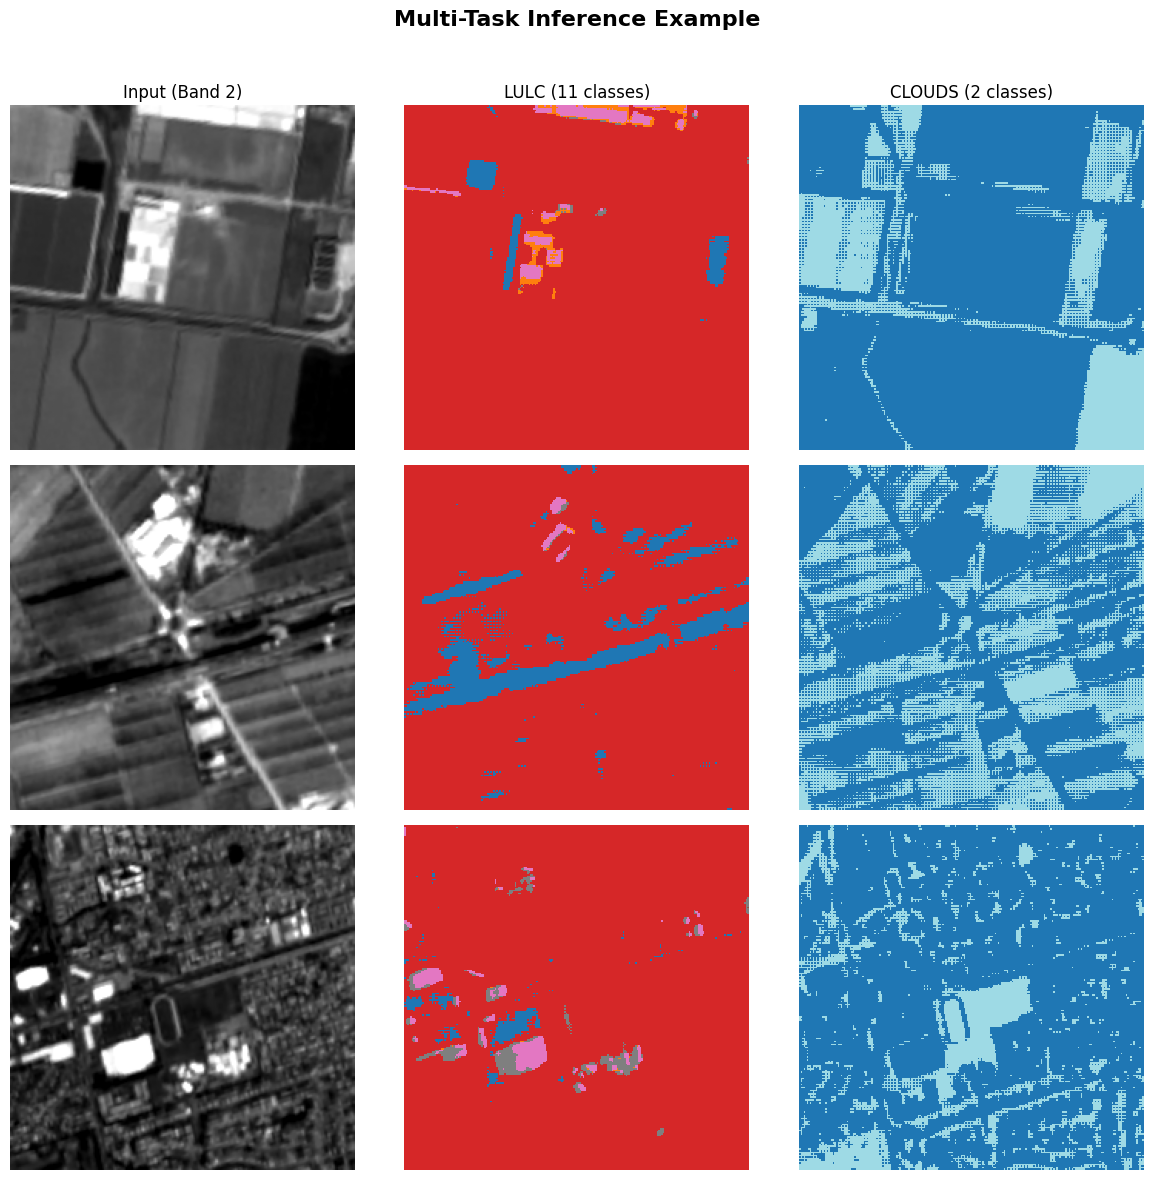

In [16]:
visualize_multi_task_inference(
    original_image_tensor_raw=imgs,
    inference_results=results,
    title="Multi-Task Inference Example",
    num_samples=3
)